# 🎨 Global Primates Watch — Visualizações Avançadas

Este notebook cria visualizações profissionais e interativas:
- Mapas interativos com Plotly
- Gráficos de barras ordenados por risco
- Heatmaps de densidade de espécies
- Visualizações de distribuição por continente
- Exportação de figuras de alta qualidade

## 📦 Importações e Configuração

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json

# Configurar estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Cores para categorias IUCN (padrão internacional)
IUCN_COLORS = {
    'EX': '#000000',   # Preto - Extinto
    'EW': '#0d0d0d',   # Cinza muito escuro - Extinto na Natureza
    'CR': '#d81e05',   # Vermelho - Criticamente em Perigo
    'EN': '#fc7f3f',   # Laranja - Em Perigo
    'VU': '#f9e814',   # Amarelo - Vulnerável
    'NT': '#cce2a0',   # Verde claro - Quase Ameaçado
    'LC': '#69b342',   # Verde - Pouco Preocupante
    'DD': '#d3d3d3',   # Cinza - Dados Insuficientes
    'NE': '#ffffff'    # Branco - Não Avaliado
}

print("✓ Importações concluídas!")

✓ Importações concluídas!


In [2]:
# Carregar dados
geojson_path = project_root / 'data' / 'processed' / 'primates_map.geojson'
csv_path = project_root / 'data' / 'processed' / 'primates_species_clean.csv'

gdf = gpd.read_file(str(geojson_path))
df = pd.read_csv(str(csv_path))

print(f"✓ Dados carregados: {len(df)} espécies")

✓ Dados carregados: 526 espécies


## 🗺️ Mapa Interativo com Plotly

In [23]:
# Preparar dados para mapa coroplético
gdf_map = gdf.copy()
gdf_map['geometry'] = gdf_map.geometry.simplify(tolerance=0.1)
gdf_map = gdf_map.merge(df[['sci_name', 'category', 'category_pt', 'risco']], on='sci_name', how='left', suffixes=('', '_df'))

# Criar mapa com Plotly (usando GeoJSON)
fig = px.choropleth_mapbox(
    gdf_map,
    geojson=gdf_map.geometry.__geo_interface__,
    locations=gdf_map.index,
    color='category',
    color_discrete_map=IUCN_COLORS,
    hover_name='sci_name',
    hover_data={'category_pt': True, 'risco': True, 'category': False},
    title='Distribuição Global de Primatas por Status IUCN',
    mapbox_style='open-street-map',
    zoom=1,
    center={'lat': 0, 'lon': 0}
)

fig.update_layout(
    height=700,
    title_font_size=16,
    font_size=12,
    hovermode='closest'
)

# Salvar mapa
output_dir = project_root / 'outputs'
output_dir.mkdir(parents=True, exist_ok=True)
map_path = output_dir / 'primates_interactive_map.html'
fig.write_html(str(map_path))

print(f"✓ Mapa interativo salvo: {map_path}")

C:\Users\eferro\AppData\Local\Temp\ipykernel_32668\2008374110.py:7: DeprecationWarning:

*choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



✓ Mapa interativo salvo: c:\Users\eferro\Desktop\Global Primates Watch\outputs\primates_interactive_map.html


## 📊 Gráfico de Barras Ordenado por Risco

In [4]:
# Contar espécies por categoria (ordenado por gravidade)
category_order = ['EX', 'EW', 'CR', 'EN', 'VU', 'NT', 'LC', 'DD', 'NE']
category_counts = df['category'].value_counts().reindex(category_order, fill_value=0)

# Criar DataFrame para plotagem
plot_data = pd.DataFrame({
    'Categoria': category_counts.index,
    'Espécies': category_counts.values,
    'Descrição': [
        'Extinto',
        'Extinto na Natureza',
        'Criticamente em Perigo',
        'Em Perigo',
        'Vulnerável',
        'Quase Ameaçado',
        'Pouco Preocupante',
        'Dados Insuficientes',
        'Não Avaliado'
    ]
})

# Criar gráfico com Plotly
fig = px.bar(
    plot_data,
    x='Categoria',
    y='Espécies',
    color='Categoria',
    color_discrete_map=IUCN_COLORS,
    hover_data={'Descrição': True, 'Espécies': True},
    title='Distribuição de Primatas por Categoria IUCN',
    labels={'Espécies': 'Número de Espécies', 'Categoria': 'Categoria IUCN'}
)

fig.update_layout(
    height=500,
    title_font_size=16,
    font_size=12,
    showlegend=False,
    xaxis_title='Categoria IUCN (do mais para o menos ameaçado)',
    yaxis_title='Número de Espécies'
)

# Salvar gráfico
bar_path = output_dir / 'primates_by_category.html'
fig.write_html(str(bar_path))

print(f"✓ Gráfico de barras salvo: {bar_path}")

✓ Gráfico de barras salvo: c:\Users\eferro\Desktop\Global Primates Watch\outputs\primates_by_category.html


## 🔥 Heatmap de Densidade de Espécies Ameaçadas

In [5]:
# Preparar dados para heatmap
threatened_gdf = gdf_map[gdf_map['risco'].isin(['Alto Risco', 'Crítico'])].copy()

# Extrair coordenadas dos centróides
threatened_gdf['lat'] = threatened_gdf.geometry.centroid.y
threatened_gdf['lon'] = threatened_gdf.geometry.centroid.x

# Criar mapa de densidade com Plotly
fig = px.density_mapbox(
    threatened_gdf,
    lat='lat',
    lon='lon',
    zoom=1,
    mapbox_style='open-street-map',
    title='Hotspots de Espécies de Primatas Ameaçadas',
    color_continuous_scale='Reds',
    hover_name='sci_name',
    hover_data={'lat': False, 'lon': False}
)

fig.update_layout(
    height=700,
    title_font_size=16,
    font_size=12,
    coloraxis_colorbar=dict(title='Densidade')
)

# Salvar mapa de densidade
heatmap_path = output_dir / 'primates_density_heatmap.html'
fig.write_html(str(heatmap_path))

print(f"✓ Heatmap de densidade salvo: {heatmap_path}")

✓ Heatmap de densidade salvo: c:\Users\eferro\Desktop\Global Primates Watch\outputs\primates_density_heatmap.html


C:\Users\eferro\AppData\Local\Temp\ipykernel_32668\726778783.py:5: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


C:\Users\eferro\AppData\Local\Temp\ipykernel_32668\726778783.py:6: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


C:\Users\eferro\AppData\Local\Temp\ipykernel_32668\726778783.py:9: DeprecationWarning:

*density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



## 🌍 Distribuição por Continente

In [6]:
# Classificar continentes por longitude
gdf_map['lat'] = gdf_map.geometry.centroid.y
gdf_map['lon'] = gdf_map.geometry.centroid.x

def classify_continent(lon):
    if -180 <= lon < -60:
        return 'América'
    elif -60 <= lon < 40:
        return 'África'
    elif 40 <= lon < 100:
        return 'Ásia'
    elif 100 <= lon <= 180:
        return 'Oceania'
    return 'Desconhecido'

gdf_map['continente'] = gdf_map['lon'].apply(classify_continent)

# Contar por continente e categoria
continent_category = gdf_map.groupby(['continente', 'category']).size().reset_index(name='count')

# Criar gráfico empilhado
fig = px.bar(
    continent_category,
    x='continente',
    y='count',
    color='category',
    color_discrete_map=IUCN_COLORS,
    title='Distribuição de Primatas por Continente e Status IUCN',
    labels={'count': 'Número de Espécies', 'continente': 'Continente', 'category': 'Categoria IUCN'},
    barmode='stack'
)

fig.update_layout(
    height=600,
    title_font_size=16,
    font_size=12,
    xaxis_title='Continente',
    yaxis_title='Número de Espécies'
)

# Salvar gráfico
continent_path = output_dir / 'primates_by_continent.html'
fig.write_html(str(continent_path))

print(f"✓ Gráfico por continente salvo: {continent_path}")

✓ Gráfico por continente salvo: c:\Users\eferro\Desktop\Global Primates Watch\outputs\primates_by_continent.html


C:\Users\eferro\AppData\Local\Temp\ipykernel_32668\3619054522.py:2: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


C:\Users\eferro\AppData\Local\Temp\ipykernel_32668\3619054522.py:3: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.




## 📈 Visualizações Estáticas com Matplotlib (para publicação)

✓ Análise resumida salva: c:\Users\eferro\Desktop\Global Primates Watch\outputs\primates_summary_analysis.png


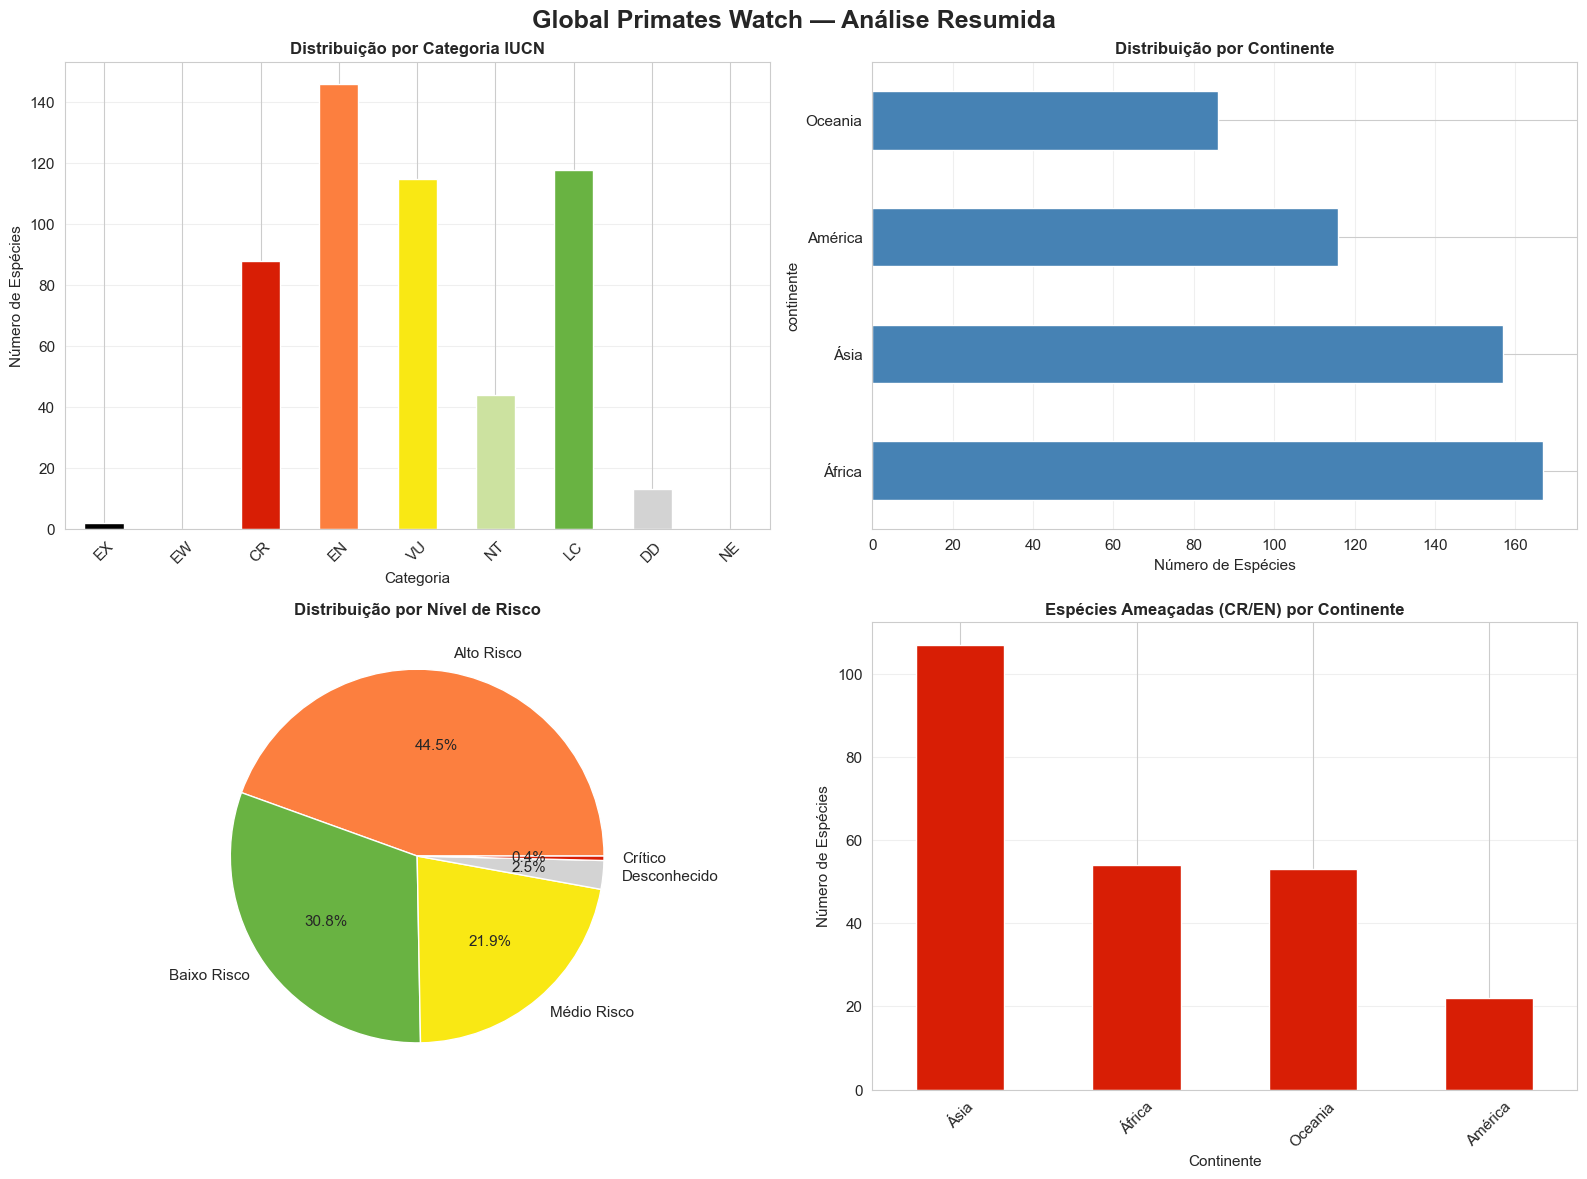

In [7]:
# Criar figura com múltiplos subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Global Primates Watch — Análise Resumida', fontsize=18, fontweight='bold')

# 1. Distribuição por categoria
ax1 = axes[0, 0]
category_counts.plot(kind='bar', ax=ax1, color=[IUCN_COLORS.get(cat, '#cccccc') for cat in category_counts.index])
ax1.set_title('Distribuição por Categoria IUCN', fontsize=12, fontweight='bold')
ax1.set_xlabel('Categoria')
ax1.set_ylabel('Número de Espécies')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# 2. Distribuição por continente
ax2 = axes[0, 1]
continent_dist = gdf_map['continente'].value_counts()
continent_dist.plot(kind='barh', ax=ax2, color='steelblue')
ax2.set_title('Distribuição por Continente', fontsize=12, fontweight='bold')
ax2.set_xlabel('Número de Espécies')
ax2.grid(axis='x', alpha=0.3)

# 3. Distribuição por nível de risco
ax3 = axes[1, 0]
risk_dist = df['risco'].value_counts()
colors_risk = {'Crítico': '#d81e05', 'Alto Risco': '#fc7f3f', 'Médio Risco': '#f9e814', 'Baixo Risco': '#69b342', 'Desconhecido': '#d3d3d3'}
risk_dist.plot(kind='pie', ax=ax3, colors=[colors_risk.get(risk, '#cccccc') for risk in risk_dist.index], autopct='%1.1f%%')
ax3.set_title('Distribuição por Nível de Risco', fontsize=12, fontweight='bold')
ax3.set_ylabel('')

# 4. Espécies ameaçadas por continente
ax4 = axes[1, 1]
threatened_by_continent = gdf_map[gdf_map['risco'].isin(['Alto Risco', 'Crítico'])]['continente'].value_counts()
threatened_by_continent.plot(kind='bar', ax=ax4, color='#d81e05')
ax4.set_title('Espécies Ameaçadas (CR/EN) por Continente', fontsize=12, fontweight='bold')
ax4.set_xlabel('Continente')
ax4.set_ylabel('Número de Espécies')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Salvar figura
summary_path = output_dir / 'primates_summary_analysis.png'
plt.savefig(str(summary_path), dpi=300, bbox_inches='tight')

print(f"✓ Análise resumida salva: {summary_path}")

## 📋 Resumo de Visualizações Criadas

In [8]:
print("="*70)
print("VISUALIZAÇÕES CRIADAS COM SUCESSO")
print("="*70)

import os

output_files = sorted(os.listdir(output_dir))

print(f"\n📁 Arquivos em {output_dir}:")
for i, file in enumerate(output_files, 1):
    file_path = output_dir / file
    file_size = os.path.getsize(file_path) / 1024  # KB
    print(f"  {i}. {file} ({file_size:.1f} KB)")

print(f"\n✓ Total: {len(output_files)} visualizações criadas")

VISUALIZAÇÕES CRIADAS COM SUCESSO

📁 Arquivos em c:\Users\eferro\Desktop\Global Primates Watch\outputs:
  1. feature_importance.csv (0.2 KB)
  2. feature_importance.png (112.5 KB)
  3. primates_by_category.html (4741.0 KB)
  4. primates_by_continent.html (4739.9 KB)
  5. primates_density_heatmap.html (4753.1 KB)
  6. primates_interactive_map.html (600343.8 KB)
  7. primates_summary_analysis.png (404.6 KB)
  8. species_threat_predictions.csv (25.8 KB)
  9. threat_prediction_model.pkl (767.2 KB)

✓ Total: 9 visualizações criadas
